In [1]:
# ============================================================
# [0] 🔑 선형 SVM 분류기 (Linear SVM Classification)
# ============================================================
# 💡 SVM(Support Vector Machine)이란?
# - 두 클래스 사이의 "가장 넓은 도로"(마진)를 찾는 분류기
# - 도로 경계에 있는 샘플 = 서포트 벡터(support vector)
#
# 📌 데이터 준비:
# - Iris 데이터에서 petal length, petal width 두 특성만 사용
# - y = (iris.target == 2): virginica vs 나머지 (이진 분류)
#
# 📌 파이프라인 구성:
# - StandardScaler: SVM은 특성 스케일에 매우 민감! (필수 전처리)
# - LinearSVC: 선형 SVM 분류기
#   - C=1: 규제 강도의 역수
#     - C 크게 → 마진 좁아짐, 훈련 오차 감소 (과대적합 위험)
#     - C 작게 → 마진 넓어짐, 일반화 성능 ↑ (과소적합 위험)
# ============================================================

from sklearn.datasets import load_iris
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 2)

svm_clf = make_pipeline(StandardScaler(), LinearSVC(C=1, random_state=42))
svm_clf.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvc', LinearSVC(C=1, random_state=42))])

In [2]:
# [1] 💡 새 데이터 예측
#     [5.5, 1.7]과 [5.0, 1.5] 두 샘플의 클래스 예측
#     - True: virginica
#     - False: 나머지

X_new = [[5.5, 1.7], [5.0, 1.5]]
svm_clf.predict(X_new)

array([ True, False])

In [3]:
# ============================================================
# [2] 🔑 decision_function - SVM의 결정 점수
# ============================================================
# 💡 로지스틱 회귀의 predict_proba와 달리 SVM은 확률 대신 "거리"를 반환
# - 값의 부호: 양수면 양성 클래스, 음수면 음성 클래스
# - 값의 절댓값: 결정 경계로부터의 거리 (클수록 확신)
#
# ⚠️ LinearSVC는 기본적으로 predict_proba를 지원하지 않음
#    (확률이 필요하면 probability=True 옵션의 SVC 사용)
# ============================================================

svm_clf.decision_function(X_new)

array([ 0.66163816, -0.22035761])

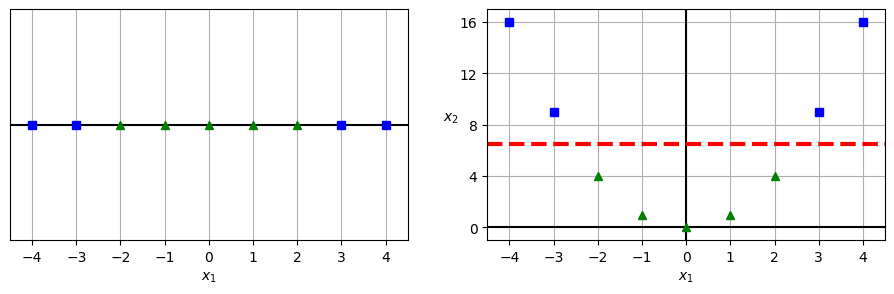

In [4]:
# ============================================================
# [3] 💡 비선형 데이터를 선형으로 분류하는 핵심 아이디어
# ============================================================
# 🎯 "특성을 추가해서 차원을 늘리면 선형 분리가 가능해질 수 있다!"
#
# 📌 예시:
# - 왼쪽(1D): 숫자 직선에 파란점-초록점-파란점 → 직선 하나로 분리 불가
# - 오른쪽(2D): x² 특성을 추가하면 포물선 형태 → 수평 직선으로 분리 가능!
#
# 💡 이게 바로 다항 특성 추가, 커널 트릭의 핵심 아이디어
# - "원래는 비선형인 문제를 고차원으로 올리면 선형이 된다"
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

X1D = np.linspace(-4, 4, 9).reshape(-1, 1)
X2D = np.c_[X1D, X1D**2]
y = np.array([0, 0, 1, 1, 1, 1, 1, 0, 0])

plt.figure(figsize=(10, 3))

plt.subplot(121)
plt.grid(True)
plt.axhline(y=0, color='k')
plt.plot(X1D[:, 0][y==0], np.zeros(4), "bs")
plt.plot(X1D[:, 0][y==1], np.zeros(5), "g^")
plt.gca().get_yaxis().set_ticks([])
plt.xlabel("$x_1$")
plt.axis([-4.5, 4.5, -0.2, 0.2])

plt.subplot(122)
plt.grid(True)
plt.axhline(y=0, color='k')
plt.axvline(x=0, color='k')
plt.plot(X2D[:, 0][y==0], X2D[:, 1][y==0], "bs")
plt.plot(X2D[:, 0][y==1], X2D[:, 1][y==1], "g^")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$  ", rotation=0)
plt.gca().get_yaxis().set_ticks([0, 4, 8, 12, 16])
plt.plot([-4.5, 4.5], [6.5, 6.5], "r--", linewidth=3)
plt.axis([-4.5, 4.5, -1, 17])

plt.subplots_adjust(right=1)
plt.show()

In [5]:
# ============================================================
# [4] 🔑 다항 특성(Polynomial Features)을 이용한 비선형 분류
# ============================================================
# 💡 make_moons: 반달 모양 데이터 (선형으로 분리 불가능한 대표적 예)
# - noise=0.15: 약간의 노이즈 추가
#
# 📌 파이프라인 전략:
# 1. PolynomialFeatures(degree=3): 3차 다항 특성 추가 (x, x², x³, xy 등)
# 2. StandardScaler: 확장된 특성들 스케일링
# 3. LinearSVC: 고차원 공간에서 선형 SVM 적용
#
# → 선형 SVM인데 비선형 분류가 가능해짐!
# ============================================================

from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures

X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

polynomial_svm_clf = make_pipeline(
    PolynomialFeatures(degree=3),
    StandardScaler(),
    LinearSVC(C=10, max_iter=10_000, random_state=42)
)
polynomial_svm_clf.fit(X, y)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=3)),
                ('standardscaler', StandardScaler()),
                ('linearsvc',
                 LinearSVC(C=10, max_iter=10000, random_state=42))])

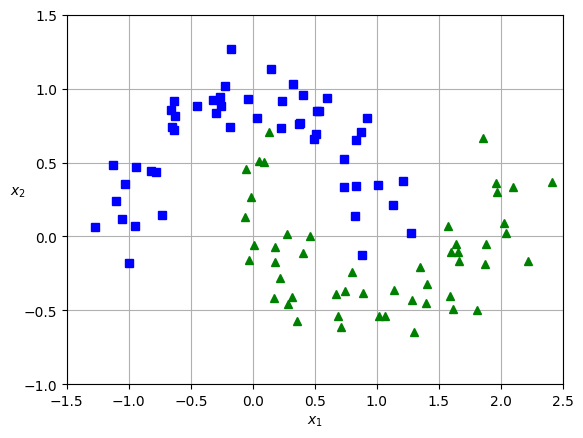

In [6]:
# [5] 💡 make_moons 데이터 시각화 - 반달 두 개가 얽혀있는 모양
#      명백히 직선 하나로는 분리 불가

def plot_dataset(X, y, axes):
  plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs")
  plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^")
  plt.axis(axes)
  plt.grid(True)
  plt.xlabel("$x_1$")
  plt.ylabel("$x_2$", rotation=0)

plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.show()

In [7]:
# ============================================================
# [6] 🔑 다항 커널 SVM (Polynomial Kernel SVM)
# ============================================================
# 💡 커널 트릭(Kernel Trick)의 마법:
# - PolynomialFeatures로 실제 특성을 만들지 않고도,
# - 고차 다항 특성을 추가한 것과 "수학적으로 동등한" 결과를 얻음!
# - 특성을 실제로 생성하지 않아 메모리/계산 효율적
#
# 📌 SVC(kernel="poly") 매개변수:
# - degree=3: 3차 다항 커널
# - coef0=1: 높은 차수 vs 낮은 차수의 영향 조절
#   (값이 크면 고차 특성의 영향이 커짐)
# - C=5: 규제 역수
# ============================================================

from sklearn.svm import SVC

poly_kernel_svm_clf = make_pipeline(StandardScaler(),
                                    SVC(kernel="poly", degree=3, coef0=1, C=5))
poly_kernel_svm_clf.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=5, coef0=1, kernel='poly'))])

In [8]:
# ============================================================
# [7] 🔑 RBF 커널 SVM (Radial Basis Function) - 가장 많이 쓰는 커널
# ============================================================
# 💡 RBF 커널의 아이디어:
# - "랜드마크(중심점)로부터의 거리"를 특성으로 사용
# - 각 샘플이 모든 샘플과의 유사도를 특성으로 가짐 (무한 차원!)
# - 가우시안 함수 형태: exp(-γ · ||x - x'||²)
#
# 📌 SVC(kernel="rbf") 매개변수:
# - gamma (γ): 각 샘플의 영향 범위
#   - γ 크게 → 각 샘플 영향이 좁음, 결정 경계가 구불구불 (과대적합)
#   - γ 작게 → 각 샘플 영향이 넓음, 결정 경계가 매끄러움 (과소적합)
# - C: 규제 역수 (마진 vs 오차 트레이드오프)
#
# 💡 gamma와 C는 서로 반대 방향으로 조절해야 균형이 맞음
#
# ⚠️ 어떤 커널을 쓸지 모를 때는 RBF부터 시도! (가장 일반적으로 좋은 성능)
# ============================================================

rbf_kernel_svm_clf = make_pipeline(StandardScaler(),
                                   SVC(kernel="rbf", gamma=5, C=0.001))
rbf_kernel_svm_clf.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=0.001, gamma=5))])

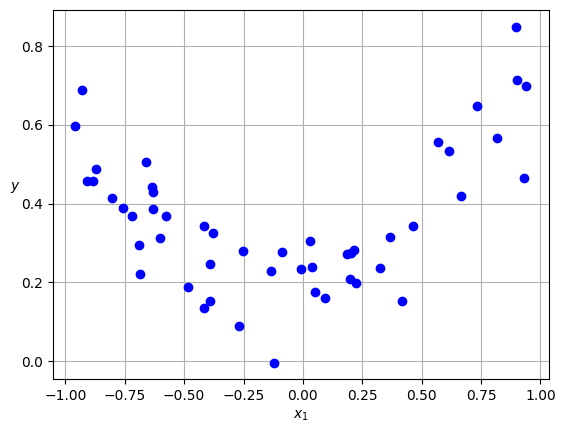

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svr', SVR(C=0.01, degree=2, kernel='poly'))])

In [9]:
# ============================================================
# [8] 🔑 SVM 회귀 (SVR) - 분류의 반대 개념
# ============================================================
# 💡 SVM 분류 vs SVM 회귀:
# - 분류: 두 클래스 사이 "가장 넓은 도로"를 만듦 (마진 최대화)
# - 회귀: 샘플들을 "도로 위에" 최대한 많이 넣음 (마진 안에 포함)
#
# 📌 SVR(kernel="poly") 매개변수:
# - degree=2: 2차 다항 커널 (y = 0.2 + 0.1x + 0.5x² 형태 데이터용)
# - C=0.01: 규제 (작을수록 규제 강함, 도로 더 평평)
# - epsilon=0.1: 도로 폭 (허용 오차 범위)
#   - 이 범위 안의 오차는 무시하고 밖으로 벗어난 것만 페널티
#
# 💡 선형 SVR: LinearSVR, 비선형 SVR: SVR (분류와 동일한 구조)
# ============================================================

from sklearn.svm import LinearSVR
from sklearn.svm import SVR

np.random.seed(42)
X = 2 * np.random.rand(50, 1) - 1
y = 0.2 + 0.1 * X[:, 0] + 0.5 * X[:, 0] ** 2 + np.random.randn(50) / 10

plt.plot(X, y, "bo")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.grid()
plt.show()

svm_poly_reg = make_pipeline(StandardScaler(),
                             SVR(kernel="poly", degree=2, C=0.01, epsilon=0.1))
svm_poly_reg.fit(X, y)

In [10]:
# ============================================================
# [9] 🎓 연습문제 1: 와인 데이터로 SVM 분류
# ============================================================
# 💡 와인 데이터셋:
# - 3종류의 와인 분류 (class_0, class_1, class_2)
# - 13개 화학 성분 특성 (알코올, 말산, 회분 등)
# - 178개 샘플
#
# DESCR로 데이터셋 설명 출력
# ============================================================

from sklearn.datasets import load_wine
wine = load_wine(as_frame=True)

print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [11]:
# [10] 🔑 훈련/테스트 세트 분할 (기본 75/25)
#       와인 분류 실습 준비

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(wine.data, wine.target, random_state=42)

X_train.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
100,12.08,2.08,1.70,17.5,97.0,2.23,2.17,0.26,1.40,3.30,1.27,2.96,710.0
122,12.42,4.43,2.73,26.5,102.0,2.20,2.13,0.43,1.71,2.08,0.92,3.12,365.0
154,12.58,1.29,2.10,20.0,103.0,1.48,0.58,0.53,1.40,7.60,0.58,1.55,640.0
51,13.83,1.65,2.60,17.2,94.0,2.45,2.99,0.22,2.29,5.60,1.24,3.37,1265.0


In [12]:
# [11] 타깃 확인 - 0, 1, 2 세 클래스

y_train.head()

,target
2,0
100,1
122,1
154,2
51,0


In [13]:
# ============================================================
# [12] ⚠️ 스케일링 없이 LinearSVC 시도 - 수렴 문제 발생!
# ============================================================
# 💡 SVM은 특성 스케일에 매우 민감
# - 스케일이 제각각이면 최적화가 느려지거나 수렴 실패
# - ConvergenceWarning이 뜰 가능성 높음
# ============================================================

lin_clf = LinearSVC(random_state=42)
lin_clf.fit(X_train, y_train)

LinearSVC(random_state=42)

In [14]:
# ============================================================
# [13] 💡 max_iter를 극단적으로 늘려서 억지로 수렴시키기
# ============================================================
# - max_iter=1,000,000: 100만 번 반복
# - 시간이 오래 걸리고 근본적 해결책이 아님
# - 진짜 해결책은 다음 셀처럼 스케일링!
# ============================================================

lin_clf = LinearSVC(max_iter=1_000_000, random_state=42)
lin_clf.fit(X_train, y_train)

LinearSVC(max_iter=1000000, random_state=42)

In [15]:
# [14] 스케일링 없는 모델의 교차 검증 정확도
#      별로 좋지 않은 결과 (예: 0.85 전후)

from sklearn.model_selection import cross_val_score

cross_val_score(lin_clf, X_train, y_train).mean()

np.float64(0.90997150997151)

In [16]:
# ============================================================
# [15] ✅ 스케일링 추가! - 파이프라인으로 해결
# ============================================================
# 💡 StandardScaler를 추가하는 것만으로:
# - 수렴 속도 대폭 개선 (max_iter=1000 기본값으로 충분)
# - 정확도도 상승!
#
# 교훈: SVM 쓸 땐 반드시 스케일링부터!
# ============================================================

lin_clf = make_pipeline(StandardScaler(), LinearSVC(random_state=42))
lin_clf.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvc', LinearSVC(random_state=42))])

In [17]:
# [16] 💡 스케일링 후 교차 검증 점수 - [14]보다 높아짐

from sklearn.model_selection import cross_val_score

cross_val_score(lin_clf, X_train, y_train).mean()

np.float64(0.9774928774928775)

In [18]:
# ============================================================
# [17] 🔑 RandomizedSearchCV로 SVC 하이퍼파라미터 튜닝
# ============================================================
# 💡 LinearSVC 대신 SVC(RBF 커널)로 업그레이드
# - SVC는 gamma 매개변수가 있어 비선형 커널 사용 가능
#
# 📌 탐색 분포:
# - loguniform(0.001, 0.1): 로그 스케일에서 균등 샘플링
#   (gamma는 배수로 변해야 의미가 있어서 로그 스케일 사용)
# - uniform(1, 10): C는 1부터 1+10=11 범위에서 선형 샘플링
#
# 📌 설정:
# - n_iter=100: 100개의 무작위 조합 시도
# - cv=5: 5-폴드 교차 검증
# - random_state=42: 재현성
#
# ⚠️ 파이프라인 접두사 주의: "svc__" (make_pipeline이 자동 생성한 이름)
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform

svm_clf = make_pipeline(StandardScaler(), SVC(random_state=42))

param_distrib = {
    "svc__gamma": loguniform(0.001, 0.1),
    "svc__C": uniform(1, 10)
}
rnd_search_cv = RandomizedSearchCV(svm_clf, param_distrib,
                                   n_iter=100, cv=5, random_state=42)
rnd_search_cv.fit(X_train, y_train)
rnd_search_cv.best_estimator_

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc',
                 SVC(C=np.float64(9.925589984899778),
                     gamma=np.float64(0.011986281799901188),
                     random_state=42))])

In [19]:
# [18] 💡 최적 조합의 교차 검증 점수 (best_score_)
#      → 대략 0.97~0.98 정도 나올 것

rnd_search_cv.best_score_

np.float64(0.9925925925925926)

In [20]:
# ============================================================
# [19] 🎯 테스트 세트 최종 평가
# ============================================================
# - rnd_search_cv.score(): best_estimator_로 자동 평가
# - 테스트 세트에서도 높은 정확도 확인
# - 훈련 세트 교차 검증 점수와 비슷하면 일반화 잘 된 것
# ============================================================

rnd_search_cv.score(X_test, y_test)

0.9777777777777777

In [21]:
# ============================================================
# [20] 🎓 연습문제 2: 캘리포니아 주택 가격 예측 (회귀)
# ============================================================
# 💡 2장에서 다뤘던 데이터셋 재등장
# - 이번엔 SVR(SVM 회귀)로 예측
# - 20,640개 샘플 × 8개 특성
# - 타깃: 주택 중간 가격 (단위: 10만 달러)
# ============================================================

from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
X = housing.data
y = housing.target

In [22]:
# [21] 훈련/테스트 분할 (80/20)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
# ============================================================
# [22] 🔑 LinearSVR로 주택 가격 예측
# ============================================================
# 💡 왜 LinearSVR (LinearSVC의 회귀 버전):
# - 큰 데이터셋(16,000개 훈련 샘플)에 SVR(커널)은 너무 느림
# - LinearSVR은 선형이라 훨씬 빠름
# - max_iter=5000: 수렴을 위해 반복 횟수 늘림
#
# ⚠️ 필수: StandardScaler 먼저 적용!
# ============================================================

from sklearn.svm import LinearSVR

lin_svr = make_pipeline(StandardScaler(), LinearSVR(max_iter=5000, random_state=42))
lin_svr.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvr', LinearSVR(max_iter=5000, random_state=42))])

In [24]:
# ============================================================
# [23] 💡 훈련 세트 MSE 계산
# ============================================================
# - mean_squared_error: 평균 제곱 오차
# - 단위는 "(10만 달러)²" (타깃 스케일이 10만 달러 단위라)
# ============================================================

from sklearn.metrics import mean_squared_error

y_pred = lin_svr.predict(X_train)
mse = mean_squared_error(y_train, y_pred)
mse

0.9595484665813285

In [25]:
# [24] 💡 RMSE(제곱근)로 변환
#      - 단위가 타깃과 같아져 해석이 쉬움
#      - 예: RMSE = 0.98 → 예측이 평균적으로 약 $98,000 빗나감
#      - 2장 랜덤 포레스트($49,000 수준)보다 성능이 낮음
#      → 개선 아이디어: 커널 SVR 사용, 하이퍼파라미터 튜닝

np.sqrt(mse)

np.float64(0.979565447829459)